In [88]:
import numbers

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
import warnings

In [89]:
warnings.filterwarnings("ignore")

ACCENT_PALETTE = ['#58a6ff', '#3fb950', '#f78166', '#d2a8ff', '#ffa657', '#79c0ff', '#f85149', '#56d4dd']

pd.set_option({
    "display.max_rows": None,
    "display.max_columns": None,
    "display.width": None,
    "display.max_colwidth": None,
})

plt.rcParams.update({
    'figure.facecolor': '#0d1117',

    'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d',
    'axes.labelcolor': '#c9d1d9',
    'axes.titlecolor': '#e6edf3',
    'axes.prop_cycle': plt.cycler(color=ACCENT_PALETTE),

    'xtick.color': '#8b949e',
    'ytick.color': '#8b949e',
    'text.color': '#c9d1d9',

    'axes.grid': True,
    'axes.axisbelow': True,
    'grid.color': '#cccccc',
    'grid.linestyle': "--",
    'grid.alpha': 0.75,

    'legend.facecolor': '#161b22',
    'legend.edgecolor': '#30363d',

    'font.family': 'DejaVu Sans',
    'axes.titlesize': 14,
    'axes.labelsize': 11,
})

sns.set_palette(ACCENT_PALETTE)

In [90]:
def load_data(path: str) -> pd.DataFrame:
    data_path = Path(path)

    if not data_path.exists():
        raise FileNotFoundError(f'{data_path} does not exist')

    return pd.read_csv(data_path)

cast = load_data("../data/raw-data/raw-marvel-cast.csv")
master = load_data("../data/raw-data/raw-marvel-master.csv")
rag = load_data("../data/raw-data/raw-marvel-rag.csv")
ratings = load_data("../data/raw-data/raw-marvel-ratings.csv")

In [91]:
print("==========SHAPE==========\n")
print(f"Cast: {cast.shape}")
print(f"Master: {master.shape}")
print(f"Rag: {rag.shape}")
print(f"Ratings: {ratings.shape}")

print("==========INFO==========\n")
print(f"Cast: {cast.info()}\n")
print(f"Master: {master.info()}\n")
print(f"Rag: {rag.info()}\n")
print(f"Ratings: {ratings.info()}\n")

print("==========DESCRIBE==========\n")
print(f"Cast: {cast.describe()}\n")
print(f"Master: {master.describe()}\n")
print(f"Rag: {rag.describe()}\n")
print(f"Ratings: {ratings.describe()}\n")

==========SHAPE==========

Cast: (1628, 9)
Master: (161, 50)
Rag: (161, 6)
Ratings: (554, 4)
==========INFO==========

<class 'pandas.DataFrame'>
RangeIndex: 1628 entries, 0 to 1627
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   title          1628 non-null   str    
 1   year           1628 non-null   int64  
 2   tmdb_id        1628 non-null   float64
 3   actor_name     1628 non-null   str    
 4   character      1618 non-null   str    
 5   cast_order     1628 non-null   int64  
 6   actor_tmdb_id  1628 non-null   int64  
 7   popularity     1628 non-null   float64
 8   profile_path   1538 non-null   str    
dtypes: float64(2), int64(3), str(4)
memory usage: 114.6 KB
Cast: None

<class 'pandas.DataFrame'>
RangeIndex: 161 entries, 0 to 160
Data columns (total 50 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    161 non

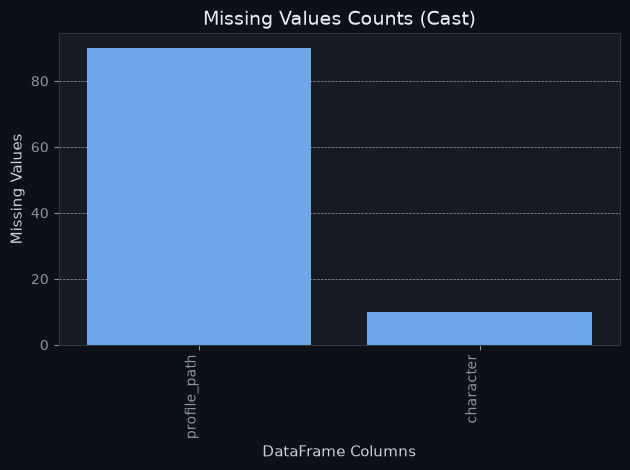

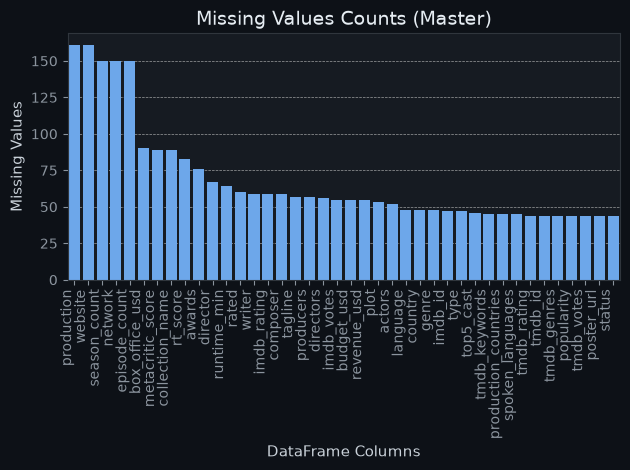

No missing values Rag


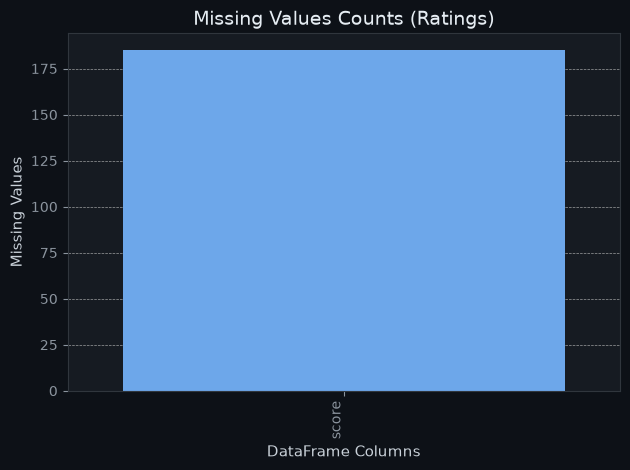

==========TOTAL NANS==========
Total NaNs: 3019


In [92]:
def make_missing_barplot(data: pd.DataFrame, name: str=""):
    missing_counts = data.isna().sum()
    missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)

    if missing_counts.empty:
        print(f"No missing values {name}")
        return missing_counts

    sns.barplot(x=missing_counts.index, y=missing_counts.values)
    plt.xticks(rotation=90, ha='right')
    plt.title(f"Missing Values Counts ({name})")
    plt.xlabel("DataFrame Columns")
    plt.ylabel("Missing Values")

    plt.tight_layout()
    plt.show()
    return missing_counts

missing_cast = make_missing_barplot(cast, name="Cast")
missing_master = make_missing_barplot(master, name="Master")
missing_rag = make_missing_barplot(rag, name="Rag")
missing_ratings = make_missing_barplot(ratings, name="Ratings")

total_missing = sum(s.sum() for s in [missing_cast, missing_master, missing_rag, missing_ratings] if s is not None)
print("==========TOTAL NANS==========")
print(f"Total NaNs: {total_missing}")

In [93]:
cast = cast.drop(columns=["profile_path"])
cast["character"] = cast["character"].fillna("Unknown")

make_missing_barplot(cast, name="Cast after cleaning")

No missing values Cast after cleaning


Series([], dtype: int64)

In [94]:
print("==========SCORE VALUE COUNTS==========\n")
print(ratings["score"].value_counts())

def normalize_row(row):
    value = row["score"]
    source = row["source"]

    if pd.isna(value):
        return np.nan

    value = str(value).strip()

    if "%" in value:
        return float(value.replace("%", "")) / 10
    elif "/" in value:
        num, denom = value.split("/")
        return float(num) / float(denom) * 10
    else:
        return float(value)

ratings["score_normalized"] = ratings.apply(normalize_row, axis=1)
ratings = ratings.drop(columns=["score"])

print("==========SCORE NORMALIZED==========\n")
print(f"Score normalized: {ratings.groupby('source')['score_normalized'].describe()}")

ratings["score_normalized"] = ratings.groupby("source")["score_normalized"].transform(
    lambda x: x.fillna(x.mean())
)

make_missing_barplot(ratings, name="Ratings after cleaning")

==========SCORE VALUE COUNTS==========

score
5.8       7
7.3       7
5.7       6
7.5       6
6.6       6
7.0       6
6.2       5
90%       5
6.9       5
5.3       4
5.6       4
7.1       4
64/100    4
6.7       4
7.4       4
85%       4
68/100    4
93%       4
7.9       4
66/100    4
6.8       4
6.3       3
6.4       3
52/100    3
63%       3
35/100    3
57/100    3
65/100    3
8.0       3
91%       3
79%       3
7.8       3
8.1       3
7.6       3
8.4       3
5.1       2
5.0       2
4.7       2
3.8       2
4.5       2
31%       2
82%       2
73/100    2
42/100    2
54/100    2
28%       2
40/100    2
94%       2
61/100    2
5.9       2
77%       2
7.7       2
69/100    2
71%       2
70/100    2
75/100    2
7.2       2
83%       2
47%       2
67/100    2
92%       2
43/100    2
6.1       2
71/100    2
5.2       2
95%       2
46%       2
5.4       1
6.038     1
6.727     1
3.5       1
3.983     1
3.7       1
50%       1
6.287     1
24%       1
63/100    1
3.2       1
16%       1
20%   

Series([], dtype: int64)

In [95]:
info_master = pd.DataFrame({
    "type": master.dtypes,
    "nan_count": master.isna().sum().values,
})

print("==========MASTER NAN INFO==========\n")
print(f"Master NaNs: {info_master[info_master["nan_count"] > 0].sort_values("nan_count", ascending=True)}")

==========MASTER NAN INFO==========

Master NaNs:                          type  nan_count
tmdb_votes            float64         44
tmdb_rating           float64         44
tmdb_genres               str         44
popularity            float64         44
tmdb_id               float64         44
poster_url                str         44
status                    str         44
tmdb_keywords             str         45
production_countries      str         45
spoken_languages          str         45
top5_cast                 str         46
imdb_id                   str         47
type                      str         47
country                   str         48
genre                     str         48
language                  str         48
actors                    str         52
plot                      str         53
budget_usd            float64         55
imdb_votes                str         55
revenue_usd           float64         55
directors                 str         56
produce

In [96]:
USELESS_COLUMNS = [
    "tmdb_id", "imdb_id", "poster_url", "website", "production"
]
master = master.drop(columns=USELESS_COLUMNS)

print("==========MASTER COLLECTION NAME COLUMN==========")
print(master["collection_name"].value_counts())

master = master.drop(columns=["collection_name"])

==========MASTER COLLECTION NAME COLUMN==========
collection_name
X-Men Collection                          5
Spider-Man (TV) Collection                4
The Incredible Hulk Collection            4
Thor Collection                           4
Captain America Collection                4
The Avengers Collection                   4
Spider-Man (MCU) Collection               4
Spider-Man Collection                     3
Iron Man Collection                       3
The Wolverine Collection                  3
Guardians of the Galaxy Collection        3
Ant-Man Collection                        3
Deadpool Collection                       3
Venom Collection                          3
Captain America (Reb Brown) Collection    2
X-Anthology                               2
Blade Collection                          2
The Punisher Collection                   2
Fantastic Four Collection                 2
Ghost Rider Collection                    2
The Amazing Spider-Man Collection         2
Doctor Str

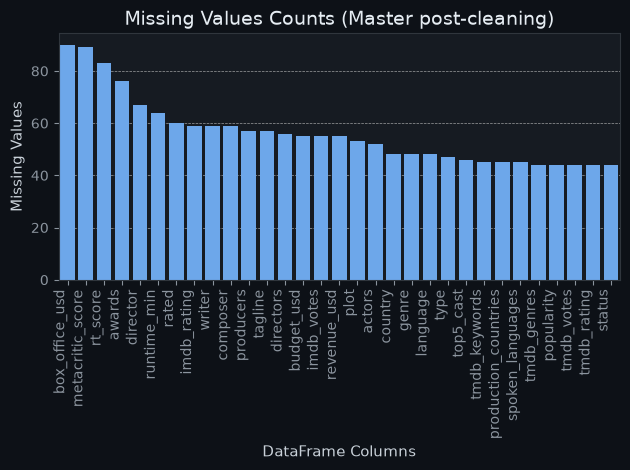

box_office_usd          90
metacritic_score        89
rt_score                83
awards                  76
director                67
runtime_min             64
rated                   60
imdb_rating             59
writer                  59
composer                59
producers               57
tagline                 57
directors               56
budget_usd              55
imdb_votes              55
revenue_usd             55
plot                    53
actors                  52
country                 48
genre                   48
language                48
type                    47
top5_cast               46
tmdb_keywords           45
production_countries    45
spoken_languages        45
tmdb_genres             44
popularity              44
tmdb_votes              44
tmdb_rating             44
status                  44
dtype: int64

In [97]:
master["season_count"] = master["season_count"].fillna(0)
master["episode_count"] = master["episode_count"].fillna(0)
master = master.drop(columns=["network"], errors="ignore")

make_missing_barplot(master, name="Master post-cleaning")

In [102]:
print("==========FAKE NUMERIC COLS==========")
print(f"Rt score: {master['rt_score'].value_counts()}\n")
print(f"Metacritic score: {master['metacritic_score'].value_counts()}\n")
print(f"Imdb votes: {master['imdb_votes'].value_counts()}\n")

master["rt_score"] = master["rt_score"].astype(str).str.replace("%", "", regex=False)
master["rt_score"] = pd.to_numeric(master["rt_score"], errors="coerce")

master["metacritic_score"] = master["metacritic_score"].astype(str).str.split("/").str[0]
master["metacritic_score"] = pd.to_numeric(master["metacritic_score"], errors="coerce")

master["imdb_votes"] = master["imdb_votes"].astype(str).str.replace(",", "", regex=False)
master["imdb_votes"] = pd.to_numeric(master["imdb_votes"], errors="coerce")

print(master[["rt_score", "metacritic_score", "imdb_votes"]].dtypes)

numeric_cols = master.select_dtypes(include="number").columns.tolist()
categorical_cols = master.select_dtypes(include="object").columns.tolist()

for col in numeric_cols:
    master[col] = master[col].fillna(master[col].median())

for col in categorical_cols:
    master[col] = master[col].fillna("Unknown")

make_missing_barplot(master, name="Master after cleaning")

==========FAKE NUMERIC COLS==========
Rt score: rt_score
76.0    83
90.0     5
85.0     4
93.0     4
63.0     3
91.0     3
79.0     3
31.0     2
82.0     2
28.0     2
94.0     2
77.0     2
71.0     2
83.0     2
47.0     2
92.0     2
95.0     2
46.0     2
50.0     1
24.0     1
16.0     1
20.0     1
59.0     1
57.0     1
42.0     1
30.0     1
11.0     1
14.0     1
56.0     1
62.0     1
38.0     1
68.0     1
29.0     1
37.0     1
72.0     1
86.0     1
80.0     1
67.0     1
51.0     1
75.0     1
9.0      1
89.0     1
96.0     1
87.0     1
97.0     1
22.0     1
36.0     1
58.0     1
15.0     1
73.0     1
84.0     1
88.0     1
Name: count, dtype: int64

Metacritic score: metacritic_score
64.0    93
68.0     4
66.0     4
52.0     3
35.0     3
57.0     3
65.0     3
73.0     2
42.0     2
54.0     2
40.0     2
61.0     2
69.0     2
70.0     2
75.0     2
67.0     2
43.0     2
71.0     2
63.0     1
47.0     1
33.0     1
83.0     1
34.0     1
58.0     1
59.0     1
45.0     1
79.0     1
30.0     1
6

Series([], dtype: int64)

In [104]:
print("==========DATAFRAMES DUPLICATES==========\n")
print(f"Cast: {cast.duplicated().sum()} duplicates\n ")
print(f"Master: {master.duplicated().sum()} duplicates\n")
print(f"Rag: {rag.duplicated().sum()} duplicates\n")
print(f"Ratings: {ratings.duplicated().sum()} duplicates\n")

==========DATAFRAMES DUPLICATES==========

Cast: 0 duplicates
 
Master: 0 duplicates

Rag: 0 duplicates

Ratings: 0 duplicates

